# Clustering Pipeline
This notebook covers the **complete clustering pipeline** in one place:

| Step | What happens |
|---|---|
| **Step 0** | Setup — libraries, config, load embeddings + metadata |
| **Step 1** | Load Precomputed Embeddings |
| **Step 2** | Elbow Method — find optimal K |
| **Step 3** | K-Means Clustering |
| **Step 4** | Cluster Label Assignment |
| **Step 5** | t-SNE Visualization |
| **Step 6** | Cluster Analysis + Per-Cluster Stats |
| **Step 7** | Save chunks_with_clusters.json |

---

> **Before running this notebook, make sure:**
> 1. All 4 data pipeline notebooks (`01` to `04`) have been fully run
> 2. `data/embeddings/faiss_index.bin` exists
> 3. `data/embeddings/chunks_with_metadata.json` exists
> 4. `data/embeddings/embeddings.npy` exists — this is the raw numpy array of all chunk embeddings saved by `embedding.ipynb`

---

**What this notebook produces:**

```
data/
└── clustering/
    ├── chunks_with_clusters.json     <- original metadata + cluster_id + cluster_label per chunk
    ├── cluster_summary.json          <- per-cluster stats (size, top terms, label)
    └── tsne_plot.png                 <- 2D visualization of all chunks colored by cluster
```

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize
from sklearn.feature_extraction.text import TfidfVectorizer

print("Imports successful")

Imports successful


In [2]:
# Configuration parameters
EMBEDDINGS_DIR  = Path("../../data/embeddings")
CLUSTERING_DIR  = Path("../../data/clustering")

EMBEDDINGS_FILE = EMBEDDINGS_DIR / "embeddings.npy"            # raw float32 array — shape (N, 384)
METADATA_FILE   = EMBEDDINGS_DIR / "chunks_with_metadata.json" # chunk text + source info

K_MIN           = 3        # minimum clusters to test in elbow method
K_MAX           = 12       # maximum clusters to test in elbow method
K_FINAL         = 6        # final number of clusters — adjust after inspecting elbow plot
RANDOM_STATE    = 42       # seed for reproducibility across KMeans and t-SNE
TOP_TERMS       = 10       # number of top TF-IDF terms to show per cluster for labeling

CLUSTERING_DIR.mkdir(parents=True, exist_ok=True)

print(f"Embeddings file  : {EMBEDDINGS_FILE}")
print(f"Metadata file    : {METADATA_FILE}")
print(f"Output directory : {CLUSTERING_DIR}")
print(f"K range          : {K_MIN} to {K_MAX}")
print(f"K final          : {K_FINAL}")
print(f"Random state     : {RANDOM_STATE}")

Embeddings file  : ..\..\data\embeddings\embeddings.npy
Metadata file    : ..\..\data\embeddings\chunks_with_metadata.json
Output directory : ..\..\data\clustering
K range          : 3 to 12
K final          : 6
Random state     : 42


---
## Load Embeddings + Chunk Metadata

We load two things here:

- **Embeddings array** — the raw float32 numpy array saved by `embedding.ipynb`. Shape is `(N, 384)` where N is the total number of chunks and 384 is the `all-MiniLM-L6-v2` embedding dimension.
- **Chunk metadata** — the JSON file containing text, bank name, source file, and page number for every chunk.

We re-normalize the embeddings to unit length before clustering. This ensures that K-Means distances reflect cosine similarity, which is consistent with how FAISS retrieval works in the RAG pipeline.

In [3]:
# Load embeddings
print("Loading embeddings...")
embeddings = np.load(str(EMBEDDINGS_FILE)).astype(np.float32)
print(f"Embeddings loaded  | Shape: {embeddings.shape} | dtype: {embeddings.dtype}")

# L2-normalize embeddings so that Euclidean distance in K-Means
# approximates cosine distance — consistent with FAISS inner product search
embeddings_norm = normalize(embeddings, norm="l2")
print(f"Embeddings normalized (L2)")

# Load chunk metadata
print("\nLoading chunk metadata...")
with open(METADATA_FILE, "r", encoding="utf-8") as f:
    chunks = json.load(f)
print(f"Chunks loaded      | Total: {len(chunks)}")

# Sanity check — embeddings and chunks must match exactly
assert embeddings_norm.shape[0] == len(chunks), (
    f"Mismatch: {embeddings_norm.shape[0]} embeddings vs {len(chunks)} chunks. "
    "Re-run 04_embedding.ipynb."
)
print("\nEmbeddings and metadata are in sync — ready to cluster")

Loading embeddings...
Embeddings loaded  | Shape: (207, 384) | dtype: float32
Embeddings normalized (L2)

Loading chunk metadata...
Chunks loaded      | Total: 207

Embeddings and metadata are in sync — ready to cluster


---
## Elbow Method — Find Optimal K

Before running K-Means we need to decide how many clusters (K) to use.

**How the Elbow Method works:**
- Run K-Means for K = 3, 4, 5 ... 12
- For each K, record the **inertia** — the sum of squared distances from each point to its assigned cluster center
- Plot inertia vs K
- The optimal K is where the curve **bends sharply** — adding more clusters after this point gives diminishing returns

After inspecting the plot, update `K_FINAL` in the config cell above and re-run from Step 3.

In [4]:
# Run K-Means for each K value and record inertia
print(f"Running Elbow Method for K = {K_MIN} to {K_MAX}...\n")

k_values = list(range(K_MIN, K_MAX + 1))
inertias = []

for k in k_values:
    km = KMeans(
        n_clusters=k,
        init="k-means++",   # smarter centroid initialization — faster convergence than random
        n_init=10,          # run 10 times with different seeds, keep best result
        max_iter=300,
        random_state=RANDOM_STATE
    )
    km.fit(embeddings_norm)
    inertias.append(km.inertia_)
    print(f"   K = {k:2d} | Inertia: {km.inertia_:.4f}")

print("\nElbow Method complete.")

Running Elbow Method for K = 3 to 12...

   K =  3 | Inertia: 128.3765
   K =  4 | Inertia: 123.7990
   K =  5 | Inertia: 120.1842
   K =  6 | Inertia: 117.2697
   K =  7 | Inertia: 114.0653
   K =  8 | Inertia: 111.6696
   K =  9 | Inertia: 108.4729
   K = 10 | Inertia: 107.0406
   K = 11 | Inertia: 106.0641
   K = 12 | Inertia: 104.5821

Elbow Method complete.


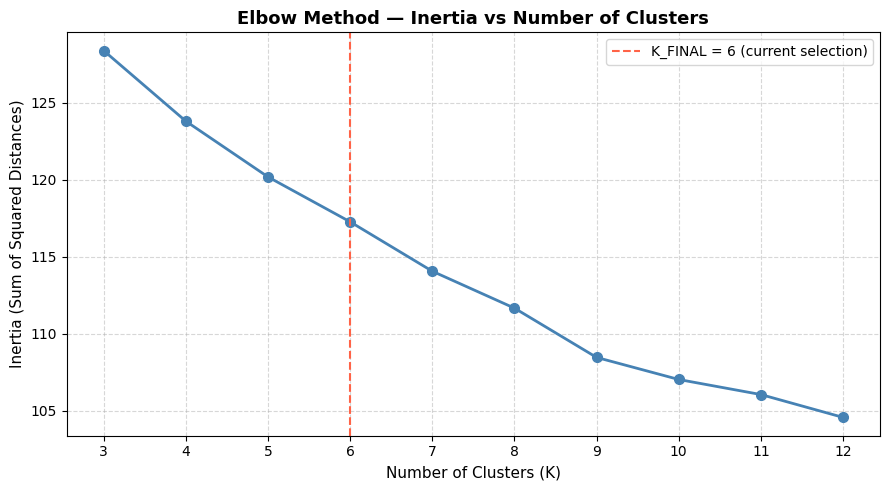

Elbow plot saved to ..\..\data\clustering\elbow_plot.png

Inspect the plot above. If the elbow is at a different K,
update K_FINAL in the config cell and re-run from Step 3.


In [5]:
# Plot the elbow curve
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(k_values, inertias, marker="o", linewidth=2, markersize=7, color="steelblue")
ax.axvline(x=K_FINAL, color="tomato", linestyle="--", linewidth=1.5,
           label=f"K_FINAL = {K_FINAL} (current selection)")

ax.set_title("Elbow Method — Inertia vs Number of Clusters", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of Clusters (K)", fontsize=11)
ax.set_ylabel("Inertia (Sum of Squared Distances)", fontsize=11)
ax.set_xticks(k_values)
ax.legend(fontsize=10)
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(CLUSTERING_DIR / "elbow_plot.png", dpi=150)
plt.show()
print(f"Elbow plot saved to {CLUSTERING_DIR / 'elbow_plot.png'}")
print(f"\nInspect the plot above. If the elbow is at a different K,")
print(f"update K_FINAL in the config cell and re-run from Step 3.")

---
## K-Means Clustering

We run K-Means with the selected `K_FINAL` value.

**Algorithm settings:**
- `init = k-means++` — selects initial centroids that are spread apart, leading to faster and more stable convergence compared to random initialization
- `n_init = 10` — runs the full algorithm 10 times with different starting points and keeps the run with lowest inertia
- `max_iter = 300` — maximum iterations per run before stopping

Each chunk gets a `cluster_id` integer from `0` to `K_FINAL - 1`.

In [6]:
# Run final K-Means with K_FINAL clusters
print(f"Running K-Means with K = {K_FINAL}...")

kmeans = KMeans(
    n_clusters=K_FINAL,
    init="k-means++",
    n_init=10,
    max_iter=300,
    random_state=RANDOM_STATE
)
kmeans.fit(embeddings_norm)

# cluster_ids[i] = cluster assigned to chunk i
cluster_ids = kmeans.labels_

print(f"Clustering complete")
print(f"   Final inertia : {kmeans.inertia_:.4f}")
print(f"   Clusters      : {K_FINAL}")
print(f"\nCluster distribution:")

unique, counts = np.unique(cluster_ids, return_counts=True)
for cluster_id, count in zip(unique, counts):
    bar = "|" * int(count / max(counts) * 30)
    print(f"   Cluster {cluster_id} : {count:3d} chunks  {bar}")

Running K-Means with K = 6...
Clustering complete
   Final inertia : 117.2697
   Clusters      : 6

Cluster distribution:
   Cluster 0 :  39 chunks  ||||||||||||||||||||||||||||||
   Cluster 1 :  36 chunks  |||||||||||||||||||||||||||
   Cluster 2 :  36 chunks  |||||||||||||||||||||||||||
   Cluster 3 :  33 chunks  |||||||||||||||||||||||||
   Cluster 4 :  26 chunks  ||||||||||||||||||||
   Cluster 5 :  37 chunks  ||||||||||||||||||||||||||||


---
## Cluster Label Assignment

K-Means assigns numeric IDs (0, 1, 2 ...) but those are meaningless on their own.

**How we assign human-readable labels:**
1. Collect all chunk texts that belong to each cluster
2. Run TF-IDF on each cluster's texts to find the most distinctive terms
3. Print the top terms per cluster — inspect them and assign a short label
4. The label map `CLUSTER_LABELS` below is the only thing you edit manually

**Why TF-IDF for labeling:**
TF-IDF surfaces terms that are frequent within a cluster but rare across all clusters — exactly the terms that make a cluster unique. Common words like "bank", "account", "please" get downweighted automatically.

In [7]:
# Extract top TF-IDF terms per cluster to guide manual label assignment
print(f"Top {TOP_TERMS} TF-IDF terms per cluster:\n")
print("=" * 65)

# Group chunk texts by cluster
cluster_texts = {k: [] for k in range(K_FINAL)}
for chunk, cid in zip(chunks, cluster_ids):
    cluster_texts[cid].append(chunk["text"])

# Build TF-IDF vocabulary across all cluster documents
# Each cluster is treated as one big document (join all its chunk texts)
cluster_docs = [" ".join(cluster_texts[k]) for k in range(K_FINAL)]

tfidf = TfidfVectorizer(
    max_features=500,
    stop_words="english",
    ngram_range=(1, 2)   # include bigrams like "profit rate", "account opening"
)
tfidf_matrix = tfidf.fit_transform(cluster_docs)
feature_names = tfidf.get_feature_names_out()

for k in range(K_FINAL):
    # Get top-N terms by TF-IDF score for this cluster
    scores = tfidf_matrix[k].toarray()[0]
    top_indices = scores.argsort()[::-1][:TOP_TERMS]
    top_terms = [feature_names[i] for i in top_indices]

    print(f"\nCluster {k} ({len(cluster_texts[k])} chunks)")
    print(f"   Top terms : {', '.join(top_terms)}")

print("\n" + "=" * 65)
print("\nInspect the top terms above and assign labels in the next cell.")

Top 10 TF-IDF terms per cluster:


Cluster 0 (39 chunks)
   Top terms : account, meezan, digital, meezan roshan, roshan, roshan digital, digital account, bank, remittance, hbl

Cluster 1 (36 chunks)
   Top terms : islamic, bank, banks, islamic banking, banking, islamic banks, financing, financial, shariah, finance

Cluster 2 (36 chunks)
   Top terms : financing, bank, 000, loan, lien, rs, payday loan, payday, years, meezan

Cluster 3 (33 chunks)
   Top terms : myabl, siri, qr, myabl digital, banking, digital banking, tickets, mastercard, account, password

Cluster 4 (26 chunks)
   Top terms : rapid, account, alfalah, alfalah rapid, bank, hbl, card, internet, payment gateway, gateway

Cluster 5 (37 chunks)
   Top terms : notes, bank, chests, bsc, sbp bsc, sbp, bsc bank, bonds, rs, coins


Inspect the top terms above and assign labels in the next cell.


In [8]:
# Manually assign a short descriptive label to each cluster
# Keys   = cluster_id integers (0 to K_FINAL - 1)
# Values = short human-readable topic label

CLUSTER_LABELS = {
    0: "Digital Accounts",
    1: "Islamic Banking",
    2: "Loans & Financing Products",
    3: "Online Services",
    4: "International Transfers & Remittances",
    5: "State Bank of Pakistan & Regulations",
}

# Validate that all cluster IDs are covered
assert set(CLUSTER_LABELS.keys()) == set(range(K_FINAL)), (
    f"CLUSTER_LABELS must have exactly {K_FINAL} entries (0 to {K_FINAL - 1}). "
    f"Currently has: {sorted(CLUSTER_LABELS.keys())}"
)

print("Cluster labels assigned:")
for cid, label in CLUSTER_LABELS.items():
    count = int(np.sum(cluster_ids == cid))
    print(f"   Cluster {cid} ({count:3d} chunks) : {label}")

Cluster labels assigned:
   Cluster 0 ( 39 chunks) : Digital Accounts
   Cluster 1 ( 36 chunks) : Islamic Banking
   Cluster 2 ( 36 chunks) : Loans & Financing Products
   Cluster 3 ( 33 chunks) : Online Services
   Cluster 4 ( 26 chunks) : International Transfers & Remittances
   Cluster 5 ( 37 chunks) : State Bank of Pakistan & Regulations


---
## t-SNE Visualization

We use **t-SNE** (t-distributed Stochastic Neighbor Embedding) to project the 384-dimensional embeddings down to 2D for visualization.

**What to look for in the plot:**
- Well-separated colored groups = good clustering, the model found distinct topic areas
- Overlapping groups = topics are genuinely similar in content, which is expected for banking FAQs
- Isolated points far from their cluster = potential mis-clustering

**t-SNE parameters:**
- `perplexity = 30` — roughly the number of nearest neighbors each point considers; 5-50 is the typical range for datasets of this size
- `n_iter = 1000` — more iterations = more stable layout
- `learning_rate = 200` — standard default; lower values can cause crowding

In [10]:
# Reduce 384-dim embeddings to 2D using t-SNE
print("Running t-SNE dimensionality reduction...")

tsne = TSNE(
    n_components=2,
    perplexity=30,
    n_iter=1000,
    learning_rate=200,
    random_state=RANDOM_STATE,
    init="pca",        # PCA init is more stable than random for high-dim data
    verbose=1
)
embeddings_2d = tsne.fit_transform(embeddings_norm)

print(f"\nt-SNE complete | Output shape: {embeddings_2d.shape}")

Running t-SNE dimensionality reduction...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 207 samples in 0.001s...
[t-SNE] Computed neighbors for 207 samples in 0.032s...
[t-SNE] Computed conditional probabilities for sample 207 / 207
[t-SNE] Mean sigma: 0.370839


c:\Python311\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] KL divergence after 250 iterations with early exaggeration: 63.324078
[t-SNE] KL divergence after 1000 iterations: 0.564538

t-SNE complete | Output shape: (207, 2)


C:\Users\Admin\AppData\Local\Temp\ipykernel_8616\2349600801.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10", K_FINAL)


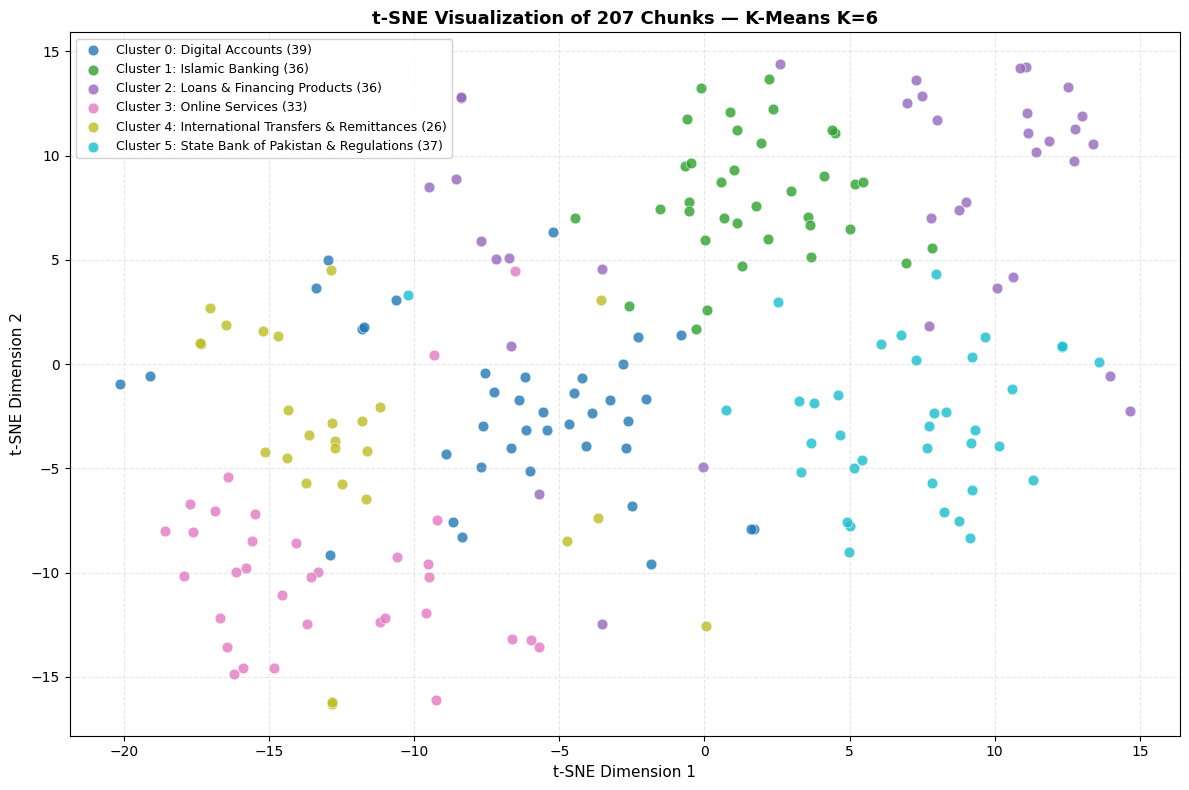

t-SNE plot saved to ..\..\data\clustering\tsne_plot.png


In [11]:
# Plot the t-SNE projection colored by cluster assignment
fig, ax = plt.subplots(figsize=(12, 8))

colors = cm.get_cmap("tab10", K_FINAL)

for k in range(K_FINAL):
    # Get 2D coordinates for all chunks in this cluster
    mask = cluster_ids == k
    x    = embeddings_2d[mask, 0]
    y    = embeddings_2d[mask, 1]
    count = int(np.sum(mask))

    ax.scatter(
        x, y,
        c=[colors(k)],
        label=f"Cluster {k}: {CLUSTER_LABELS[k]} ({count})",
        s=60,
        alpha=0.8,
        edgecolors="white",
        linewidths=0.5
    )

# Final plot adjustments
ax.set_title(
    f"t-SNE Visualization of {len(chunks)} Chunks — K-Means K={K_FINAL}",
    fontsize=13, fontweight="bold"
)
ax.set_xlabel("t-SNE Dimension 1", fontsize=11)
ax.set_ylabel("t-SNE Dimension 2", fontsize=11)
ax.legend(loc="best", fontsize=9, framealpha=0.9)
ax.grid(True, linestyle="--", alpha=0.3)

# Save and show the plot
plt.tight_layout()
plt.savefig(CLUSTERING_DIR / "tsne_plot.png", dpi=150)
plt.show()
print(f"t-SNE plot saved to {CLUSTERING_DIR / 'tsne_plot.png'}")

---
## Cluster Analysis (Per-Cluster Statistics)

Before saving, we do a detailed breakdown of each cluster:

- How many chunks belong to each cluster
- Which banks are represented in each cluster
- Which source files appear most in each cluster

This helps verify that the clusters make semantic sense — for example, the "Remittance" cluster should be dominated by HBL remittance documents, not Meezan solar financing.

In [12]:
# Attach cluster_id and cluster_label to each chunk for analysis
for i, chunk in enumerate(chunks):
    chunk["cluster_id"]    = int(cluster_ids[i])
    chunk["cluster_label"] = CLUSTER_LABELS[int(cluster_ids[i])]

# Build a dataframe for easy analysis
df = pd.DataFrame([
    {
        "chunk_id":      c.get("chunk_id", i),
        "bank_name":     c.get("bank_name", ""),
        "source_file":   c.get("source_file", ""),
        "page_number":   c.get("page_number", ""),
        "cluster_id":    c["cluster_id"],
        "cluster_label": c["cluster_label"],
        "text_length":   len(c.get("text", ""))
    }
    for i, c in enumerate(chunks)
])

print("Per-Cluster Analysis")
print("=" * 65)

cluster_summary = []

for k in range(K_FINAL):
    df_k        = df[df["cluster_id"] == k]
    bank_counts = df_k["bank_name"].value_counts().to_dict()
    file_counts = df_k["source_file"].value_counts().head(3).to_dict()
    avg_len     = round(df_k["text_length"].mean(), 1)

    print(f"\nCluster {k} — {CLUSTER_LABELS[k]}")
    print(f"   Chunks       : {len(df_k)}")
    print(f"   Avg text len : {avg_len} chars")
    print(f"   Banks        : {dict(list(bank_counts.items())[:4])}")
    print(f"   Top files    : {list(file_counts.keys())}")

    cluster_summary.append({
        "cluster_id":    k,
        "cluster_label": CLUSTER_LABELS[k],
        "chunk_count":   len(df_k),
        "avg_text_len":  avg_len,
        "bank_counts":   bank_counts,
        "top_files":     list(file_counts.keys())
    })

print("\n" + "=" * 65)

Per-Cluster Analysis

Cluster 0 — Digital Accounts
   Chunks       : 39
   Avg text len : 1372.8 chars
   Banks        : {'Meezan Bank': 24, 'Habib Bank Limited (HBL)': 12, 'Allied Bank Limited (ABL)': 2, 'Bank Alfalah': 1}
   Top files    : ['Meezan-Bank-FAQs-Roshan-Digital-Account.pdf', 'HBL-Islamic-Current-Account.pdf', 'Meezan-Bank-FAQs-Digital-Account.pdf']

Cluster 1 — Islamic Banking
   Chunks       : 36
   Avg text len : 1548.1 chars
   Banks        : {'State Bank of Pakistan (SBP)': 32, 'Habib Bank Limited (HBL)': 3, 'Allied Bank Limited (ABL)': 1}
   Top files    : ['State-Bank-FAQs-History.pdf', 'HBL-Islamic-Current-Account.pdf', 'State-Bank-FAQs.pdf']

Cluster 2 — Loans & Financing Products
   Chunks       : 36
   Avg text len : 1120.4 chars
   Banks        : {'Meezan Bank': 14, 'State Bank of Pakistan (SBP)': 9, 'Allied Bank Limited (ABL)': 8, 'Bank Alfalah': 3}
   Top files    : ['Meezan-Bank-FAQs-Salaried.pdf', 'State-Bank-FAQs.pdf', 'ABL-FAQs.pdf']

Cluster 3 — Online S

C:\Users\Admin\AppData\Local\Temp\ipykernel_8616\3207299749.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors_bar = [cm.get_cmap("tab10", K_FINAL)(k) for k in range(K_FINAL)]


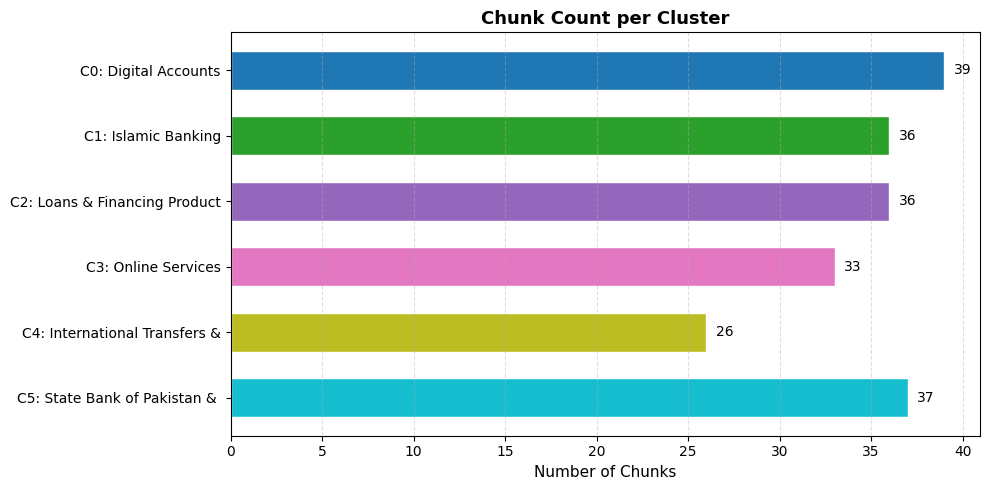

Distribution plot saved to ..\..\data\clustering\cluster_distribution.png


In [13]:
# Bar chart — chunk count per cluster
fig, ax = plt.subplots(figsize=(10, 5))

colors_bar = [cm.get_cmap("tab10", K_FINAL)(k) for k in range(K_FINAL)]
labels_short = [f"C{k}: {CLUSTER_LABELS[k][:25]}" for k in range(K_FINAL)]
counts_per_cluster = [int(np.sum(cluster_ids == k)) for k in range(K_FINAL)]

bars = ax.barh(labels_short, counts_per_cluster, color=colors_bar, edgecolor="white", height=0.6)

# Add count labels on bars
for bar, count in zip(bars, counts_per_cluster):
    ax.text(
        bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
        str(count), va="center", ha="left", fontsize=10
    )

ax.set_title("Chunk Count per Cluster", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of Chunks", fontsize=11)
ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(CLUSTERING_DIR / "cluster_distribution.png", dpi=150)
plt.show()
print(f"Distribution plot saved to {CLUSTERING_DIR / 'cluster_distribution.png'}")

---
## Save Output Files

We save two output files:

| File | Contents | Used by |
|---|---|---|
| `chunks_with_clusters.json` | All original chunk fields + `cluster_id` + `cluster_label` | `rag_pipeline_v2.ipynb` |
| `cluster_summary.json` | Per-cluster stats: size, banks, top files, label | Reference + reporting |

The original `chunks_with_metadata.json` is **not modified** — this is a new file with extra fields added.

In [14]:
# Save chunks_with_clusters.json

# This is the main output — original metadata + cluster_id + cluster_label per chunk
chunks_output_path = CLUSTERING_DIR / "chunks_with_clusters.json"
with open(chunks_output_path, "w", encoding="utf-8") as f:
    json.dump(chunks, f, ensure_ascii=False, indent=2)
print(f"chunks_with_clusters.json saved")
print(f"   Path   : {chunks_output_path}")
print(f"   Chunks : {len(chunks)}")
print(f"   Fields : {list(chunks[0].keys())}")

# Save cluster_summary.json
# Per-cluster stats for reference and reporting
summary_output_path = CLUSTERING_DIR / "cluster_summary.json"
with open(summary_output_path, "w", encoding="utf-8") as f:
    json.dump(cluster_summary, f, ensure_ascii=False, indent=2)
print(f"\ncluster_summary.json saved")
print(f"   Path     : {summary_output_path}")
print(f"   Clusters : {len(cluster_summary)}")

# Save cluster_ids as numpy array for potential reuse
np.save(str(CLUSTERING_DIR / "cluster_ids.npy"), cluster_ids)
print(f"\ncluster_ids.npy saved")
print(f"   Path  : {CLUSTERING_DIR / 'cluster_ids.npy'}")
print(f"   Shape : {cluster_ids.shape}")

chunks_with_clusters.json saved
   Path   : ..\..\data\clustering\chunks_with_clusters.json
   Chunks : 207
   Fields : ['chunk_id', 'bank_name', 'source_file', 'page_number', 'chunk_index', 'token_count', 'text', 'cluster_id', 'cluster_label']

cluster_summary.json saved
   Path     : ..\..\data\clustering\cluster_summary.json
   Clusters : 6

cluster_ids.npy saved
   Path  : ..\..\data\clustering\cluster_ids.npy
   Shape : (207,)


In [ ]:
# Final verification — print a few sample chunks from each cluster
print("Sample chunks per cluster (first chunk only)")

for k in range(K_FINAL):
    # Get first chunk belonging to this cluster
    sample = next(c for c in chunks if c["cluster_id"] == k)

    print(f"\nCluster {k} — {CLUSTER_LABELS[k]}")
    print(f"   Bank        : {sample.get('bank_name', 'N/A')}")
    print(f"   Source      : {sample.get('source_file', 'N/A')}")
    print(f"   Page        : {sample.get('page_number', 'N/A')}")
    print(f"   Text preview: {sample.get('text', '')[:120].strip()}...")

print("\n" + "=" * 65)
print("\nClustering pipeline complete. Output files:")
print(f"   {CLUSTERING_DIR / 'chunks_with_clusters.json'}")
print(f"   {CLUSTERING_DIR / 'cluster_summary.json'}")
print(f"   {CLUSTERING_DIR / 'cluster_ids.npy'}")
print(f"   {CLUSTERING_DIR / 'elbow_plot.png'}")
print(f"   {CLUSTERING_DIR / 'tsne_plot.png'}")
print(f"   {CLUSTERING_DIR / 'cluster_distribution.png'}")
print(f"\nNext step: run rag_pipeline_v2.ipynb to use cluster-aware retrieval.")

Sample chunks per cluster (first chunk only)

Cluster 0 — Digital Accounts
   Bank        : Allied Bank Limited (ABL)
   Source      : ABL-Business-User-Guidelines.pdf
   Page        : 7
   Text preview: OBDX – General Guidelines 
4. IBFT Bank Codes 
Sr. 
# 
 
 
Bank Names 
 
 
Bank Codes Sr. # 
 
 
 
Bank Names 
 
 
Bank...

Cluster 1 — Islamic Banking
   Bank        : Allied Bank Limited (ABL)
   Source      : ABL-Business-User-Guidelines.pdf
   Page        : 7
   Text preview: ALFH 
 
BAHL 
 
SCBL 
SONE 
SAUD 
MEZN 
PLCO 
BKIP 
 
TMFB 
 
AIIN 
FINC 
FMFB 
ZTBL 
KHBL 
APML 
ABPA 
TMFB 
MCBL 
BAHL...

Cluster 2 — Loans & Financing Products
   Bank        : Allied Bank Limited (ABL)
   Source      : ABL-Business-User-Guidelines.pdf
   Page        : 4
   Text preview: ) 
3.1. Bulk Fund transfers file detail 
*NOTE: - Transaction Amount in Bulk File must be inputted as per above format,...

Cluster 3 — Online Services
   Bank        : Allied Bank Limited (ABL)
   Source      : ABL-Busine

---
## Clustering Summary

| Component | Choice | Reason |
|---|---|---|
| Algorithm | K-Means | Simple, fast, interpretable — works well on normalized dense embeddings |
| Initialization | k-means++ | Smarter centroid seeding — faster convergence than random |
| K selection | Elbow Method | Visual inspection of inertia curve — no labels needed |
| Distance metric | Euclidean on L2-normalized vecs | Equivalent to cosine distance — consistent with FAISS |
| Labeling method | TF-IDF top terms | Surfaces cluster-distinctive terms automatically |
| Visualization | t-SNE | Best 2D projection for high-dim semantic embeddings |

---

### Files Generated by This Notebook

```
data/
├── embeddings/
|   ├── faiss_index.bin                <- from embedding.ipynb (unchanged)
|   ├── embeddings.npy                 <- from embedding.ipynb (unchanged)
|   └── chunks_with_metadata.json      <- from embedding.ipynb (unchanged)
|
└── clustering/
    ├── chunks_with_clusters.json      <- NEW: used by rag_pipeline_v2.ipynb
    ├── cluster_summary.json           <- NEW: per-cluster stats
    ├── cluster_ids.npy                <- NEW: raw cluster assignment array
    ├── elbow_plot.png                 <- NEW: K selection plot
    ├── tsne_plot.png                  <- NEW: 2D cluster visualization
    └── cluster_distribution.png       <- NEW: chunk count per cluster
```